# 04 · Retrieval II - Two-Tower model 

**Amazon Reviews 2023 — Electronics** · Real-time recommendation system

The two-tower model is our second retriever. It has two independent encoders:

- **user tower:** `user_id` embedding → MLP → user vector `û`
- **item tower:** `[item_id embedding ; category embedding]` → MLP → item vector `v̂`

Both outputs are **L2-normalized**, so the score is a cosine similarity `û · v̂`. Because the two towers never interact until that final dot product, we can pre-compute every item vector once and index them with **FAISS** — exactly what a real serving system does.

It generalizes matrix factorization: instead of a bare ID lookup, each side is a small neural network that can also ingest features (here, item **category**, which helps rare/cold items).

**Training uses in-batch negatives + softmax cross-entropy.** For a batch of `B` positive `(user, item)` pairs we form the `B×B` cosine matrix; the diagonal are the true pairs and every other item in the batch is a free negative. Softmax cross-entropy then pushes each user toward their own item:

$$\text{logits} = \frac{U V^\top}{\tau}, \qquad \mathcal{L} = \text{cross\_entropy}(\text{logits}, [0,1,\dots,B{-}1])$$

The model lives in `src/recsys/models/two_tower.py` (shared with the webapp); the training loop is written out below. At the end we compare **Popularity vs MF-BPR vs Two-tower** head-to-head and pick the retriever to feed the ranker.

## 0 · Setup

In [1]:
import sys, time
from pathlib import Path
try:
    import google.colab  # noqa
    from google.colab import drive; drive.mount('/content/drive')
    PROJECT = Path('/content/drive/MyDrive/rec-system')  # <-- adjust to your Drive path
except ImportError:
    PROJECT = Path('..').resolve()
DATA_DIR, ART_DIR = PROJECT / 'data', PROJECT / 'artifacts'
ART_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT / 'src'))

In [2]:
import numpy as np, pandas as pd, torch, faiss
import matplotlib.pyplot as plt
from recsys.models.two_tower import TwoTower
from recsys.metrics import evaluate_recommendations
from recsys.faiss_index import build_flat_ip, search as faiss_search

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


## 1 · Load data, build pairs and item categories

Same positive training pairs as MF-BPR. The item tower additionally needs each item's **category** as an integer id, aligned by `item_idx`.

In [3]:
SPLIT = DATA_DIR / 'splits'
train = pd.read_parquet(SPLIT / 'train.parquet')
val   = pd.read_parquet(SPLIT / 'val.parquet')
test  = pd.read_parquet(SPLIT / 'test.parquet')
items = pd.read_parquet(DATA_DIR / 'items.parquet')
n_users = int(pd.read_parquet(DATA_DIR / 'user_map.parquet').shape[0])
n_items = int(pd.read_parquet(DATA_DIR / 'item_map.parquet').shape[0])

# category id per item (aligned by item_idx; unknown -> 0)
items = items.sort_values('item_idx')
cats = items['category'].fillna('<unk>').astype('category')
cat_of_item = np.zeros(n_items, dtype=np.int64)
cat_of_item[items['item_idx'].to_numpy()] = cats.cat.codes.to_numpy() + 1  # reserve 0 for padding
n_cats = int(cat_of_item.max()) + 1

pos = train[train.positive]
users_t = torch.tensor(pos.user_idx.to_numpy(), dtype=torch.long)
items_t = torch.tensor(pos.item_idx.to_numpy(), dtype=torch.long)
n_pairs = len(users_t)
print(f'users {n_users:,} | items {n_items:,} | categories {n_cats:,} | positive pairs {n_pairs:,}')

users 25,546 | items 20,450 | categories 514 | positive pairs 212,851


In [4]:
train_users, train_items = set(train.user_idx), set(train.item_idx)
seen = {u: set(g) for u, g in train.groupby('user_idx')['item_idx']}
def build_gt(split):
    p = split[split.positive & split.user_idx.isin(train_users) & split.item_idx.isin(train_items)]
    return {int(u): set(v) for u, v in p.groupby('user_idx')['item_idx'].apply(set).items()}
val_gt, test_gt = build_gt(val), build_gt(test)
val_users, test_users = list(val_gt), list(test_gt)
print(f'val users {len(val_users):,} | test users {len(test_users):,}')

val users 9,840 | test users 6,962


## 2 · The model and the in-batch-negative loss

The loss (`TwoTower.loss`) is standard softmax cross-entropy over the batch's cosine matrix:

```python
U = normalize(user_tower(users))   # [B, d]
V = normalize(item_tower(items))   # [B, d]
logits = (U @ V.T) / temperature   # diagonal = the true pairs
loss   = cross_entropy(logits, arange(B))
```

**Hyperparameters** (tuned on validation): embedding size, hidden width, output dim, temperature `τ`, learning rate, batch size. A **larger batch** gives more in-batch negatives, which usually helps.

In [5]:
EMB, HIDDEN, OUT = 64, (128,), 64
TEMP   = 0.1          # softmax temperature
LR     = 1e-3
BATCH  = 2048         # also = number of in-batch negatives per positive
EPOCHS = 40
PATIENCE = 5

model = TwoTower(n_users, n_items, n_cats, emb=EMB, hidden=HIDDEN, out_dim=OUT, temperature=TEMP).to(device)
model.set_item_categories(cat_of_item)
opt = torch.optim.Adam(model.parameters(), lr=LR)
print('model parameters:', sum(p.numel() for p in model.parameters()))

model parameters: 3017984


### Evaluation helper

Encode **all** items with the item tower, index them with FAISS (inner product on unit vectors = cosine), then retrieve top-100 per user and drop already-seen items.

In [6]:
def evaluate_model(model, users, ground_truth, k_candidates=100):
    index = build_flat_ip(model.all_item_vectors())
    u = torch.tensor(users, dtype=torch.long, device=device)
    uvec = model.user_vectors(u)
    max_seen = max((len(seen.get(x, ())) for x in users), default=0)
    _, ids = faiss_search(index, uvec, k_candidates + max_seen)
    recs = {}
    for row, user in enumerate(users):
        s = seen.get(user, set())
        recs[user] = [int(it) for it in ids[row] if it not in s][:k_candidates]
    return evaluate_recommendations(recs, ground_truth, n_items), recs

## 3 · Training loop (written out)

Each epoch: shuffle positive pairs, and for each mini-batch compute the in-batch-negative softmax loss and take an Adam step. We track **validation NDCG@10** and keep the best weights (early stopping).

In [7]:
best_ndcg, best_state, bad, history = -1.0, None, 0, []
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    perm = torch.randperm(n_pairs)
    running = 0.0
    for start in range(0, n_pairs, BATCH):
        idx = perm[start:start + BATCH]
        if len(idx) < 2:
            continue                      # need >=2 for in-batch negatives
        u = users_t[idx].to(device); i = items_t[idx].to(device)
        loss = model.loss(u, i)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item() * len(idx)
    train_loss = running / n_pairs
    val_metrics, _ = evaluate_model(model, val_users, val_gt)
    ndcg = val_metrics['NDCG@10']
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_NDCG@10': ndcg, 'val_Recall@20': val_metrics['Recall@20']})
    flag = ''
    if ndcg > best_ndcg:
        best_ndcg, best_state, bad = ndcg, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}, 0
        flag = '  <- best'
    else:
        bad += 1
    print(f'epoch {epoch:2d} | loss {train_loss:.4f} | val NDCG@10 {ndcg:.4f} | val Recall@20 {val_metrics["Recall@20"]:.4f}{flag}')
    if bad >= PATIENCE:
        print(f'early stop (no val improvement for {PATIENCE} epochs)'); break
model.load_state_dict(best_state)
print(f'\ntrained in {time.time()-t0:.1f}s | best val NDCG@10 = {best_ndcg:.4f}')

epoch  1 | loss 7.5155 | val NDCG@10 0.0051 | val Recall@20 0.0115  <- best


epoch  2 | loss 6.8657 | val NDCG@10 0.0095 | val Recall@20 0.0193  <- best


epoch  3 | loss 6.2620 | val NDCG@10 0.0113 | val Recall@20 0.0242  <- best


epoch  4 | loss 5.6842 | val NDCG@10 0.0117 | val Recall@20 0.0259  <- best


epoch  5 | loss 5.2421 | val NDCG@10 0.0109 | val Recall@20 0.0251


...

epoch 16 | loss 4.0654 | val NDCG@10 0.0127 | val Recall@20 0.0266


epoch 17 | loss 4.0364 | val NDCG@10 0.0123 | val Recall@20 0.0269


epoch 18 | loss 4.0136 | val NDCG@10 0.0130 | val Recall@20 0.0265


epoch 19 | loss 3.9905 | val NDCG@10 0.0123 | val Recall@20 0.0273


epoch 20 | loss 3.9702 | val NDCG@10 0.0121 | val Recall@20 0.0270
early stop (no val improvement for 5 epochs)

trained in 250.5s | best val NDCG@10 = 0.0137


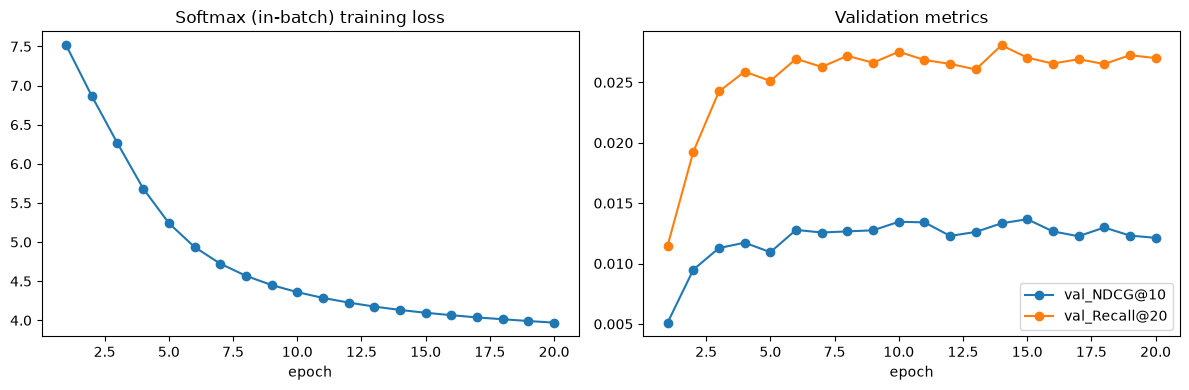

In [8]:
h = pd.DataFrame(history).set_index('epoch')
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
h['train_loss'].plot(ax=ax[0], marker='o'); ax[0].set(title='Softmax (in-batch) training loss', xlabel='epoch')
h[['val_NDCG@10', 'val_Recall@20']].plot(ax=ax[1], marker='o'); ax[1].set(title='Validation metrics', xlabel='epoch')
plt.tight_layout(); plt.show()

## 4 · Final evaluation & the three-way comparison

Score the test period and place the two-tower next to the baselines and MF-BPR. This is the headline retrieval table: **Popularity vs MF-BPR vs Two-tower**.

In [9]:
test_metrics, test_recs = evaluate_model(model, test_users, test_gt)
prev = pd.read_parquet(DATA_DIR / 'results' / 'retrieval.parquet')
cmp = pd.concat([prev, pd.DataFrame({'Two-tower': test_metrics}).T])
cmp = cmp[~cmp.index.duplicated(keep='last')]
report_cols = ['Recall@20', 'Recall@50', 'NDCG@10', 'Coverage@20']
cmp[report_cols].round(4)

,Recall@20,Recall@50,NDCG@10,Coverage@20
Random,0.0012,0.0020,0.0004,0.9987
Popularity,0.0115,0.0250,0.0034,0.0012
Recency,0.0052,0.0138,0.0016,0.0011
MF-BPR,0.0207,0.0256,0.0129,0.6847
Two-tower,0.0283,0.0369,0.0136,0.9910


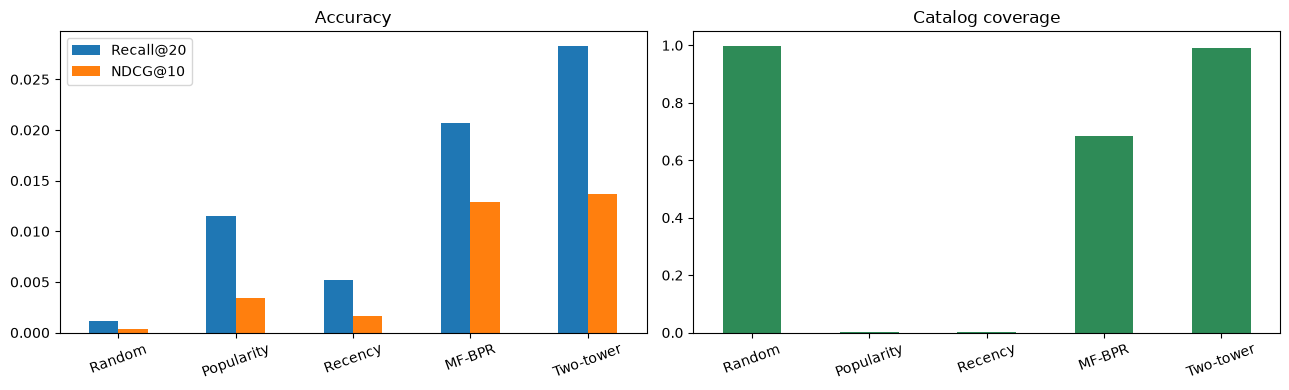

In [10]:
order = ['Random', 'Popularity', 'Recency', 'MF-BPR', 'Two-tower']
plot_df = cmp.reindex([o for o in order if o in cmp.index])
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
plot_df[['Recall@20', 'NDCG@10']].plot(kind='bar', ax=ax[0]); ax[0].set(title='Accuracy'); ax[0].tick_params(axis='x', rotation=20)
plot_df[['Coverage@20']].plot(kind='bar', ax=ax[1], color='seagreen', legend=False); ax[1].set(title='Catalog coverage'); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

> **Interpretation.** The two-tower is the **strongest retriever on every accuracy metric**: Recall@20 **0.0283** (vs MF-BPR 0.0207, ~+37%), Recall@50 **0.0369** (breaking the tie MF-BPR had with Popularity at @50), and NDCG@10 **0.0136** (edging MF-BPR's 0.0129) — while covering **99% of the catalog**. Its edge comes from the MLP towers plus the **item-category feature** (richer than MF's bare ID dot-product) and the large in-batch-negative signal from a 2048-row batch. Both learned retrievers crush the non-personalized baselines. Because the two-tower is best on NDCG@10 (and everything else), it is the retriever we feed into the LightGBM ranker next.

## 5 · Export artifacts

Save the trained towers, all item vectors, and a FAISS index. The webapp's *"similar items"* and *"because you liked X"* sections use these item embeddings (cosine nearest neighbours).

In [11]:
torch.save(model.state_dict(), ART_DIR / 'two_tower.pt')
np.save(ART_DIR / 'two_tower_item_emb.npy', model.all_item_vectors())
faiss.write_index(build_flat_ip(model.all_item_vectors()), str(ART_DIR / 'two_tower_faiss.index'))
np.save(ART_DIR / 'item_categories.npy', cat_of_item)
cmp.to_parquet(DATA_DIR / 'results' / 'retrieval.parquet')
print('saved artifacts ->', ART_DIR)
for p in sorted(ART_DIR.glob('two_tower*')): print(' ', p.name, f'{p.stat().st_size/1e6:.2f} MB')

saved artifacts -> F:\Rec_System\artifacts
  two_tower.pt 12.24 MB
  two_tower_faiss.index 5.24 MB
  two_tower_item_emb.npy 5.24 MB


---


**Produced:** a two-tower retriever trained from scratch with in-batch negatives + softmax cross-entropy and L2-normalized (cosine) scoring, evaluated via FAISS, plus the full **Popularity vs MF-BPR vs Two-tower** comparison. Item embeddings + FAISS index exported for the webapp's similarity features.

